In [2]:
import pandas as pd
import json

with open("balanced_flight_telemetry.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
print(df.head())

              timestamp flight_info.callsign  flight_info.airframe_hours  \
0  2026-04-09T10:00:00Z           VIT-AI-400                14250.500000   
1  2026-04-09T10:00:01Z           VIT-AI-400                14250.500278   
2  2026-04-09T10:00:02Z           VIT-AI-400                14250.500556   
3  2026-04-09T10:00:03Z           VIT-AI-400                14250.500833   
4  2026-04-09T10:00:04Z           VIT-AI-400                14250.501111   

  flight_info.flight_phase  kinematics.altitude_ft  kinematics.airspeed_knots  \
0                  TAKEOFF                     0.0                     280.52   
1                  TAKEOFF                     0.0                     282.23   
2                  TAKEOFF                     0.0                     278.10   
3                  TAKEOFF                     0.0                     279.41   
4                  TAKEOFF                     0.0                     281.05   

   kinematics.g_force_axial  propulsion_sys.engine_1_egt

C:\Users\nlsan\AppData\Local\Temp\ipykernel_14232\1222275819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')


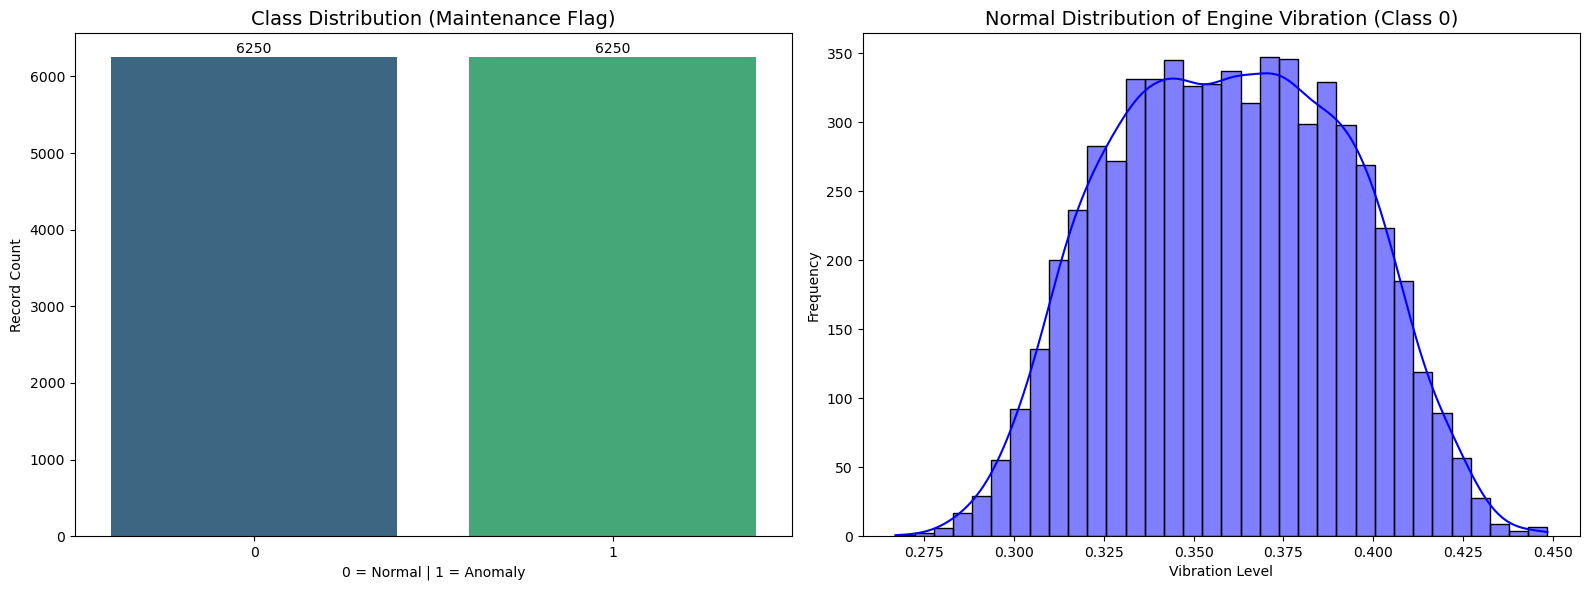

--- Data Summary ---
Total Vehicles: 5
Class Counts:
analytics_meta.maintenance_flag
0    6250
1    6250
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Load the data
with open('balanced_flight_telemetry.json', 'r') as f:
    data = json.load(f)

# 2. Flatten JSON into a DataFrame
df = pd.json_normalize(data)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: Class Distribution (Bar Chart) ---
sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (Maintenance Flag)', fontsize=14)
axes[0].set_xlabel('0 = Normal | 1 = Anomaly')
axes[0].set_ylabel('Record Count')

# Add text labels on the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

# --- GRAPH 2: Normal Distribution (Sensor Bell Curves) ---
# We plot the vibration distribution for the "Normal" state (flag 0) 
# to see the clean Gaussian curve before the anomaly drift begins.
normal_data = df[df['analytics_meta.maintenance_flag'] == 0]

sns.histplot(normal_data['propulsion_sys.engine_1_vibration'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Normal Distribution of Engine Vibration (Class 0)', fontsize=14)
axes[1].set_xlabel('Vibration Level')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print Summary
print("--- Data Summary ---")
print(f"Total Vehicles: {df['flight_info.callsign'].nunique()}")
print(f"Class Counts:\n{df['analytics_meta.maintenance_flag'].value_counts()}")

# Preprocessing

In [4]:
# ================================
# PREPROCESSING STEPS
# ================================

# 1. Check basic info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 2. Handle Missing Values
# Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Remove Duplicates
df.drop_duplicates(inplace=True)

# 4. Convert Timestamp to Datetime
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# 5. Feature Engineering (optional but useful)
# Example: Extract hour from timestamp
if 'timestamp' in df.columns:
    df['hour'] = df['timestamp'].dt.hour

# 6. Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    try:
        df[col] = le.fit_transform(df[col])
    except:
        pass  # skip complex nested fields

# 7. Normalize / Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 8. Handle Outliers (Optional)
# Remove extreme values using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("\nPreprocessing Completed ✅")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   timestamp                          12500 non-null  object 
 1   flight_info.callsign               12500 non-null  object 
 2   flight_info.airframe_hours         12500 non-null  float64
 3   flight_info.flight_phase           12500 non-null  object 
 4   kinematics.altitude_ft             12500 non-null  float64
 5   kinematics.airspeed_knots          12500 non-null  float64
 6   kinematics.g_force_axial           12500 non-null  float64
 7   propulsion_sys.engine_1_egt_c      12500 non-null  float64
 8   propulsion_sys.engine_1_vibration  12500 non-null  float64
 9   propulsion_sys.fuel_remaining_lbs  12500 non-null  float64
 10  analytics_meta.maintenance_flag    12500 non-null  int64  
dtypes: float64(7), int64(1), object(3)
memor

C:\Users\nlsan\AppData\Local\Temp\ipykernel_14232\2889246517.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Preprocessing Completed ✅
   timestamp  flight_info.callsign  flight_info.airframe_hours  \
0          0                     0                   -1.731358   
1          1                     0                   -1.729972   
2          2                     0                   -1.728587   
3          3                     0                   -1.727201   
4          4                     0                   -1.725816   

   flight_info.flight_phase  kinematics.altitude_ft  \
0                         3               -1.023148   
1                         3               -1.023148   
2                         3               -1.023148   
3                         3               -1.023148   
4                         3               -1.023148   

   kinematics.airspeed_knots  kinematics.g_force_axial  \
0                   0.249842                 -1.969284   
1                   1.100561                  0.001798   
2                  -0.954099                  0.396014   
3            